## Setup

In [ ]:
!pip install scikit-fuzzy
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 29.7 MB/s eta 0:00:00


## Universes and Variables

In [ ]:
# Fuzzy tree with three systems:
# 1) Food Quality (temperature, flavor, portion_size) -> food_quality
# 2) Service Quality (attentiveness, friendliness, speed) -> service_quality
# 3) Tipper (food_quality, service_quality) -> tip

# Inputs (Antecedents)
temperature = ctrl.Antecedent(np.linspace(0, 10, 11), 'temperature')
flavor = ctrl.Antecedent(np.linspace(0, 10, 11), 'flavor')
portion_size = ctrl.Antecedent(np.linspace(0, 10, 11), 'portion_size')
attentiveness = ctrl.Antecedent(np.linspace(0, 10, 11), 'attentiveness')
friendliness = ctrl.Antecedent(np.linspace(0, 10, 11), 'friendliness')
speed = ctrl.Antecedent(np.linspace(0, 10, 11), 'speed')

# Stage 1 Outputs (Consequents)
food_quality = ctrl.Consequent(np.linspace(0, 10, 11), 'food_quality')
service_quality = ctrl.Consequent(np.linspace(0, 10, 11), 'service_quality')

# Tip Stage Inputs (New antecedents to avoid dependency loops)
food_quality_for_tip = ctrl.Antecedent(np.linspace(0, 10, 11), 'food_quality_for_tip')
service_quality_for_tip = ctrl.Antecedent(np.linspace(0, 10, 11), 'service_quality_for_tip')

# Final Output
tip = ctrl.Consequent(np.linspace(0, 25, 26), 'tip')

## Membership Functions

In [ ]:
# Automatically generate 'poor', 'average', 'good' membership functions
var_names = [temperature, flavor, portion_size,attentiveness, friendliness, speed, food_quality, service_quality,food_quality_for_tip, service_quality_for_tip, tip]
for var in var_names:
  var.automf(3)

## Rules

In [ ]:
# Food Quality (Stage 1)
rule1_food = ctrl.Rule(temperature['poor'] | flavor['poor'] | portion_size['poor'], food_quality['poor'])
rule2_food = ctrl.Rule(temperature['good'] & flavor['good'], food_quality['good'])
rule3_food = ctrl.Rule(flavor['good'] & portion_size['good'],food_quality['good'])
rule4_food = ctrl.Rule(temperature['average'] & flavor['average'], food_quality['average'])
rule5_food = ctrl.Rule(temperature['good'] & portion_size['average'], food_quality['average'])
rule6_food = ctrl.Rule(temperature['good'] & portion_size['good'], food_quality['good'])

# Collect Food rules
food_ctrl = ctrl.ControlSystem([rule1_food, rule2_food, rule3_food, rule4_food, rule5_food])

# Service Quality (Stage 1)
rule1_service = ctrl.Rule(attentiveness['poor'] | friendliness['poor'] | speed['poor'], service_quality['poor'])
rule2_service = ctrl.Rule(attentiveness['good'] & friendliness['good'], service_quality['good'])
rule3_service = ctrl.Rule(friendliness['good'] & speed['good'], service_quality['good'])
rule4_service = ctrl.Rule(attentiveness['average'] & friendliness['average'], service_quality['average'])
rule5_service = ctrl.Rule(speed['good'] & attentiveness['average'], service_quality['average'])
rule6_service = ctrl.Rule(speed['good'] & attentiveness['good'], service_quality['good'])

# Collect service rules
service_ctrl = ctrl.ControlSystem([rule1_service, rule2_service, rule3_service, rule4_service, rule5_service])

# Tipper (Stage 2)
rule1_tip = ctrl.Rule(food_quality_for_tip['good'] & service_quality_for_tip['good'], tip['good'])
rule2_tip = ctrl.Rule(food_quality_for_tip['poor'] & service_quality_for_tip['poor'], tip['poor'])
rule3_tip = ctrl.Rule(food_quality_for_tip['good'] & service_quality_for_tip['average'], tip['average'])
rule4_tip = ctrl.Rule(food_quality_for_tip['average'] & service_quality_for_tip['good'], tip['average'])
rule5_tip = ctrl.Rule(food_quality_for_tip['average'] & service_quality_for_tip['average'],tip['average'])
rule6_tip = ctrl.Rule(food_quality_for_tip['good'] & service_quality_for_tip['poor'], tip['average'])
rule7_tip = ctrl.Rule(food_quality_for_tip['poor'] & service_quality_for_tip['good'], tip['average'])
tip_ctrl = ctrl.ControlSystem([rule1_tip, rule2_tip, rule3_tip, rule4_tip, rule5_tip, rule6_tip, rule7_tip])

## Pipeline function to compute Tip

In [ ]:
# Fresh simulations each call
# Stage 1: compute food_quality & service_quality
# Stage 2: feed those into Tipper
def compute_tip(inputs):
    # Stage 1: Food
    food_sim = ctrl.ControlSystemSimulation(food_ctrl)
    food_sim.input['temperature'] = inputs['temperature']
    food_sim.input['flavor'] = inputs['flavor']
    food_sim.input['portion_size'] = inputs['portion_size']
    food_sim.compute()
    fq = food_sim.output['food_quality']

    # Stage 1: Service
    service_sim = ctrl.ControlSystemSimulation(service_ctrl)
    service_sim.input['attentiveness'] = inputs['attentiveness']
    service_sim.input['friendliness'] = inputs['friendliness']
    service_sim.input['speed'] = inputs['speed']
    service_sim.compute()
    sq = service_sim.output['service_quality']

    # Stage 2: Tipper
    tip_sim = ctrl.ControlSystemSimulation(tip_ctrl)
    tip_sim.input['food_quality_for_tip'] = fq
    tip_sim.input['service_quality_for_tip'] = sq
    tip_sim.compute()
    tip_pct = tip_sim.output['tip']

    return {'food_quality': fq, 'service_quality': sq, 'tip_percent': tip_pct}

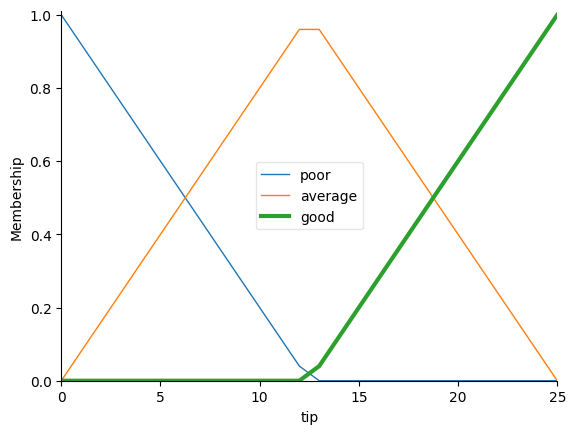

In [ ]:
tip['good'].view()

## Input Helpers and Interactive Loop

In [ ]:
# Validates user-supplied values in [0,10] and loops until user exits
def prompt_float(name):
    while True:
        try:
            v = float(input(f"Enter {name} [0–10]: "))
            if 0 <= v <= 10:
                return v
            print("Value must be between 0 and 10.")
        except ValueError:
            print("Please enter a valid number.")

def fuzzy_loop():
    print("Fuzzy Tree Tipper — enter meal ratings (0–10)")
    while True:
        vals = {
            'temperature': prompt_float('temperature'),
            'flavor': prompt_float('flavor'),
            'portion_size': prompt_float('portion size'),
            'attentiveness': prompt_float('attentiveness'),
            'friendliness': prompt_float('friendliness'),
            'speed': prompt_float('speed of service')
        }
        res = compute_tip(vals)
        print("\n--- Results ---")
        print(f"Food Quality: {res['food_quality']:.2f}")
        print(f"Service Quality: {res['service_quality']:.2f}")
        print(f"Recommended Tip: {res['tip_percent']:.2f}%")

        again = input("\nAnother meal? [y/n]: ").strip().lower()
        if not again or again[0] != 'y':
            print("Goodbye!")
            break

In [ ]:
fuzzy_loop()

Fuzzy Tree Tipper — enter meal ratings (0–10)
Enter temperature [0–10]: 9
Enter flavor [0–10]: 9
Enter portion size [0–10]: 9
Enter attentiveness [0–10]: 9
Enter friendliness [0–10]: 9
Enter speed of service [0–10]: 9

--- Results ---
Food Quality: 6.73
Service Quality: 6.73
Recommended Tip: 13.21%

Another meal? [y/n]: y
Enter temperature [0–10]: 5
Enter flavor [0–10]: 5
Enter portion size [0–10]: 5
Enter attentiveness [0–10]: 5
Enter friendliness [0–10]: 5
Enter speed of service [0–10]: 5

--- Results ---
Food Quality: 5.00
Service Quality: 5.00
Recommended Tip: 12.50%

Another meal? [y/n]: y
Enter temperature [0–10]: 1
Enter flavor [0–10]: 1
Enter portion size [0–10]: 1
Enter attentiveness [0–10]: 1
Enter friendliness [0–10]: 1
Enter speed of service [0–10]: 1

--- Results ---
Food Quality: 3.27
Service Quality: 3.27
Recommended Tip: 11.79%

Another meal? [y/n]: y
Enter temperature [0–10]: a
Please enter a valid number.
Enter temperature [0–10]: b
Please enter a valid number.
Enter 

## References:
- ECE 449 Lab 5 Presentation Slides
- ECE 449 Lab 5 PDF
- ECE 449 Lab 4 Mihir Mukhi
- ECE 449 Slides from Dr. Musilek
- skfuzzy Documentation: https://pythonhosted.org/scikit-fuzzy/auto_examples/index.html